### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from utils import * 
from FAPT import * 
from pulse_optimization import *
import sympy as sp

In [2]:
rH = 2
rW = 1
def fitted_pulse_symbolic(t, p):
    tg_sym, wd_sym, amp_sym = p
    return amp_sym, wd_sym
param_ranges = {"wd_offset": (-0.005, 0.005), "amp_scale": (0.8, 1.2)}
param_names = list(param_ranges.keys())

f_ref = 0.05572
s_ref = Simulation(f_c_dc=f_ref)
s_sym, f_c_dc_sym = make_symbolic_bias_simulation(s_ref, f_ref=f_ref)
def fitted_pulse_symbolic_with_bias(t, parameters):
    return fitted_pulse_symbolic(t, parameters[:3])
H_bias_base, M_bias_base, M_inv_0_bias_base = prepare_floquet_functions(pulse_shape_builder=fitted_pulse_symbolic_with_bias, p_names=["tg", "wd", "amp", "f_c_dc"], s=s_sym, rH=rH, rW=rW, include_geometric=False, include_micromotion=False, include_g_correction=False, verbose=True)

def bind_bias_floquet_functions(tg_target, f_c_dc, s_bias, H_bias_base=H_bias_base, M_bias_base=M_bias_base, M_inv_0_bias_base=M_inv_0_bias_base):
    cos_wd, cos_amp = compute_cos_params(s_bias, tg_target)
    def absolute_parameters(offsets):
        values = dict(zip(param_names, offsets))
        return cos_wd + values["wd_offset"], cos_amp * values["amp_scale"]
    def H_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return H_bias_base(t, tg_target, wd, amp, f_c_dc)
    def M_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return M_bias_base(t, tg_target, wd, amp, f_c_dc)
    def M_inv_0_func(*offsets):
        wd, amp = absolute_parameters(offsets)
        return M_inv_0_bias_base(tg_target, wd, amp, f_c_dc)
    H_func.is_time_dependent = getattr(H_bias_base, "is_time_dependent", True)
    return H_func, M_func, M_inv_0_func


1/2 Erstelle symbolischen Puls und berechne W und Heff ...


W-Floquet order r=1/1: 100%|██████████| 81/81 [00:00<00:00, 435.25it/s]


✅ W-elements calculation completed.
Calculating effective matrix elements (3x3)...


H_eff matrix elements: 100%|██████████| 9/9 [00:00<00:00,  9.60it/s]


✅ H_eff matrix calculation completed.
2/2 Erzeuge Lambdified H_func, M_func und M_inv_0_func ...
Operationen in Heff vor CSE: 4089


In [3]:
# from scipy.optimize import minimize_scalar

# tg_fixed = 550.0

# def objective_bias(f_c_dc, correct_zz=False):
#     f_c_dc = float(np.atleast_1d(f_c_dc)[0])
#     s_bias = Simulation(f_c_dc=f_c_dc)
#     H_func, M_func, M_inv_0_func = bind_bias_floquet_functions(tg_fixed, f_c_dc, s_bias, H_bias_base, M_bias_base, M_inv_0_bias_base)
#     result = optimize_iswap_at_gate_time(tg_fixed, s_bias, param_ranges, H_func, M_func, M_inv_0_func, verbose=False, correct_zz=correct_zz)
#     print(f"f_c_dc = {f_c_dc:+.8f} GHz, infidelity = {result['infid_direct_proc']:.3e}")
#     return result["infid_direct_proc"]

# opt_bias = minimize_scalar(objective_bias, bounds=(+0.055, 0.058), method="bounded", options={"xatol": 1e-5, "maxiter": 15})
# print(f"\nOptimal f_c_dc: {opt_bias.x:+.8f} GHz")
# print(f"Minimum infid_direct_proc: {opt_bias.fun:.6e}")

In [4]:
tg_fixed = 550.0
f_c_dc_list = np.linspace(0.05552, 0.0558, 10)  # Coupler-frequency offset [GHz]

results_bias = []

for f_c_dc in tqdm(f_c_dc_list):
    f_c_dc = float(np.atleast_1d(f_c_dc)[0])
    s_bias = Simulation(f_c_dc=f_c_dc)
    H_func, M_func, M_inv_0_func = bind_bias_floquet_functions(tg_fixed, f_c_dc, s_bias)
    result = optimize_iswap_at_gate_time_cos(tg_fixed, s_bias, param_ranges, H_func, M_func, M_inv_0_func, verbose=False)
    result["f_c_dc"] = f_c_dc
    results_bias.append(result)

result_keys_bias = results_bias[0].keys()
sweep_data_bias = {key: np.asarray([result[key] for result in results_bias]) for key in result_keys_bias}

 10%|█         | 1/10 [00:06<00:55,  6.16s/it]

tg_final: 549.1026 ns | infid_floq_pop: 5.8406e-04 | infid_floq_proc: 3.7316e-04 | infid_direct_pop: 6.0255e-04 | infid_direct_proc: 6.1754e-04


 20%|██        | 2/10 [00:11<00:47,  5.96s/it]

tg_final: 549.1025 ns | infid_floq_pop: 5.7629e-04 | infid_floq_proc: 3.6510e-04 | infid_direct_pop: 5.5803e-04 | infid_direct_proc: 5.6394e-04


 30%|███       | 3/10 [00:18<00:42,  6.08s/it]

...

tg_final: 549.1020 ns | infid_floq_pop: 5.2866e-04 | infid_floq_proc: 4.1721e-04 | infid_direct_pop: 3.8254e-04 | infid_direct_proc: 4.5323e-04


 90%|█████████ | 9/10 [00:53<00:05,  5.97s/it]

tg_final: 549.1019 ns | infid_floq_pop: 5.2130e-04 | infid_floq_proc: 4.4288e-04 | infid_direct_pop: 3.7104e-04 | infid_direct_proc: 4.7282e-04


100%|██████████| 10/10 [00:59<00:00,  5.98s/it]

tg_final: 549.1019 ns | infid_floq_pop: 5.1433e-04 | infid_floq_proc: 4.7341e-04 | infid_direct_pop: 3.6505e-04 | infid_direct_proc: 5.0388e-04


In [5]:

# without bias
s = Simulation()
tg = 550
H_base, M_base, M_inv_0_base = prepare_floquet_functions(pulse_shape_builder=fitted_pulse_symbolic, p_names=["tg", "wd", "amp"], s=s, rH=rH, rW=rW, include_geometric=False, include_micromotion=False, include_g_correction=False, verbose=True)

param_ranges = {"wd_offset": (-0.005, 0.005), "amp_scale": (0.8, 1.2)}
param_names = list(param_ranges.keys())

def bind_tg_fixed_floquet_functions(tg_target, s): 
    
    cos_wd, cos_amp = compute_cos_params(s, tg_target)
    def absolute_parameters(offsets):
        values = dict(zip(param_names, offsets))
        return cos_wd + values["wd_offset"], cos_amp * values["amp_scale"]

    def H_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return H_base(t, tg_target, wd, amp)

    def M_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return M_base(t, tg_target, wd, amp)
    def M_inv_0_func(*offsets):
        wd, amp = absolute_parameters(offsets)
        return M_inv_0_base(tg_target, wd, amp)
    H_func.is_time_dependent = getattr(H_base, "is_time_dependent", True)
    return H_func, M_func, M_inv_0_func

dic = optimize_iswap_at_gate_time_cos(tg, s, param_ranges, *bind_tg_fixed_floquet_functions(tg, s), verbose = False)


1/2 Erstelle symbolischen Puls und berechne W und Heff ...


W-Floquet order r=1/1: 100%|██████████| 81/81 [00:00<00:00, 963.13it/s]


✅ W-elements calculation completed.
Calculating effective matrix elements (3x3)...


H_eff matrix elements: 100%|██████████| 9/9 [00:00<00:00, 53.49it/s]


✅ H_eff matrix calculation completed.
2/2 Erzeuge Lambdified H_func, M_func und M_inv_0_func ...
Operationen in Heff vor CSE: 723
tg_final: 550.6503 ns | infid_floq_pop: 2.2980e-04 | infid_floq_proc: 2.4460e-04 | infid_direct_pop: 4.6729e-04 | infid_direct_proc: 7.3477e-02


/var/folders/7k/3h2gl4fs7gb1hdzh7fl2mc940000gn/T/ipykernel_35632/3869074560.py:702: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.045, 0.02, 0.98, 1.0))


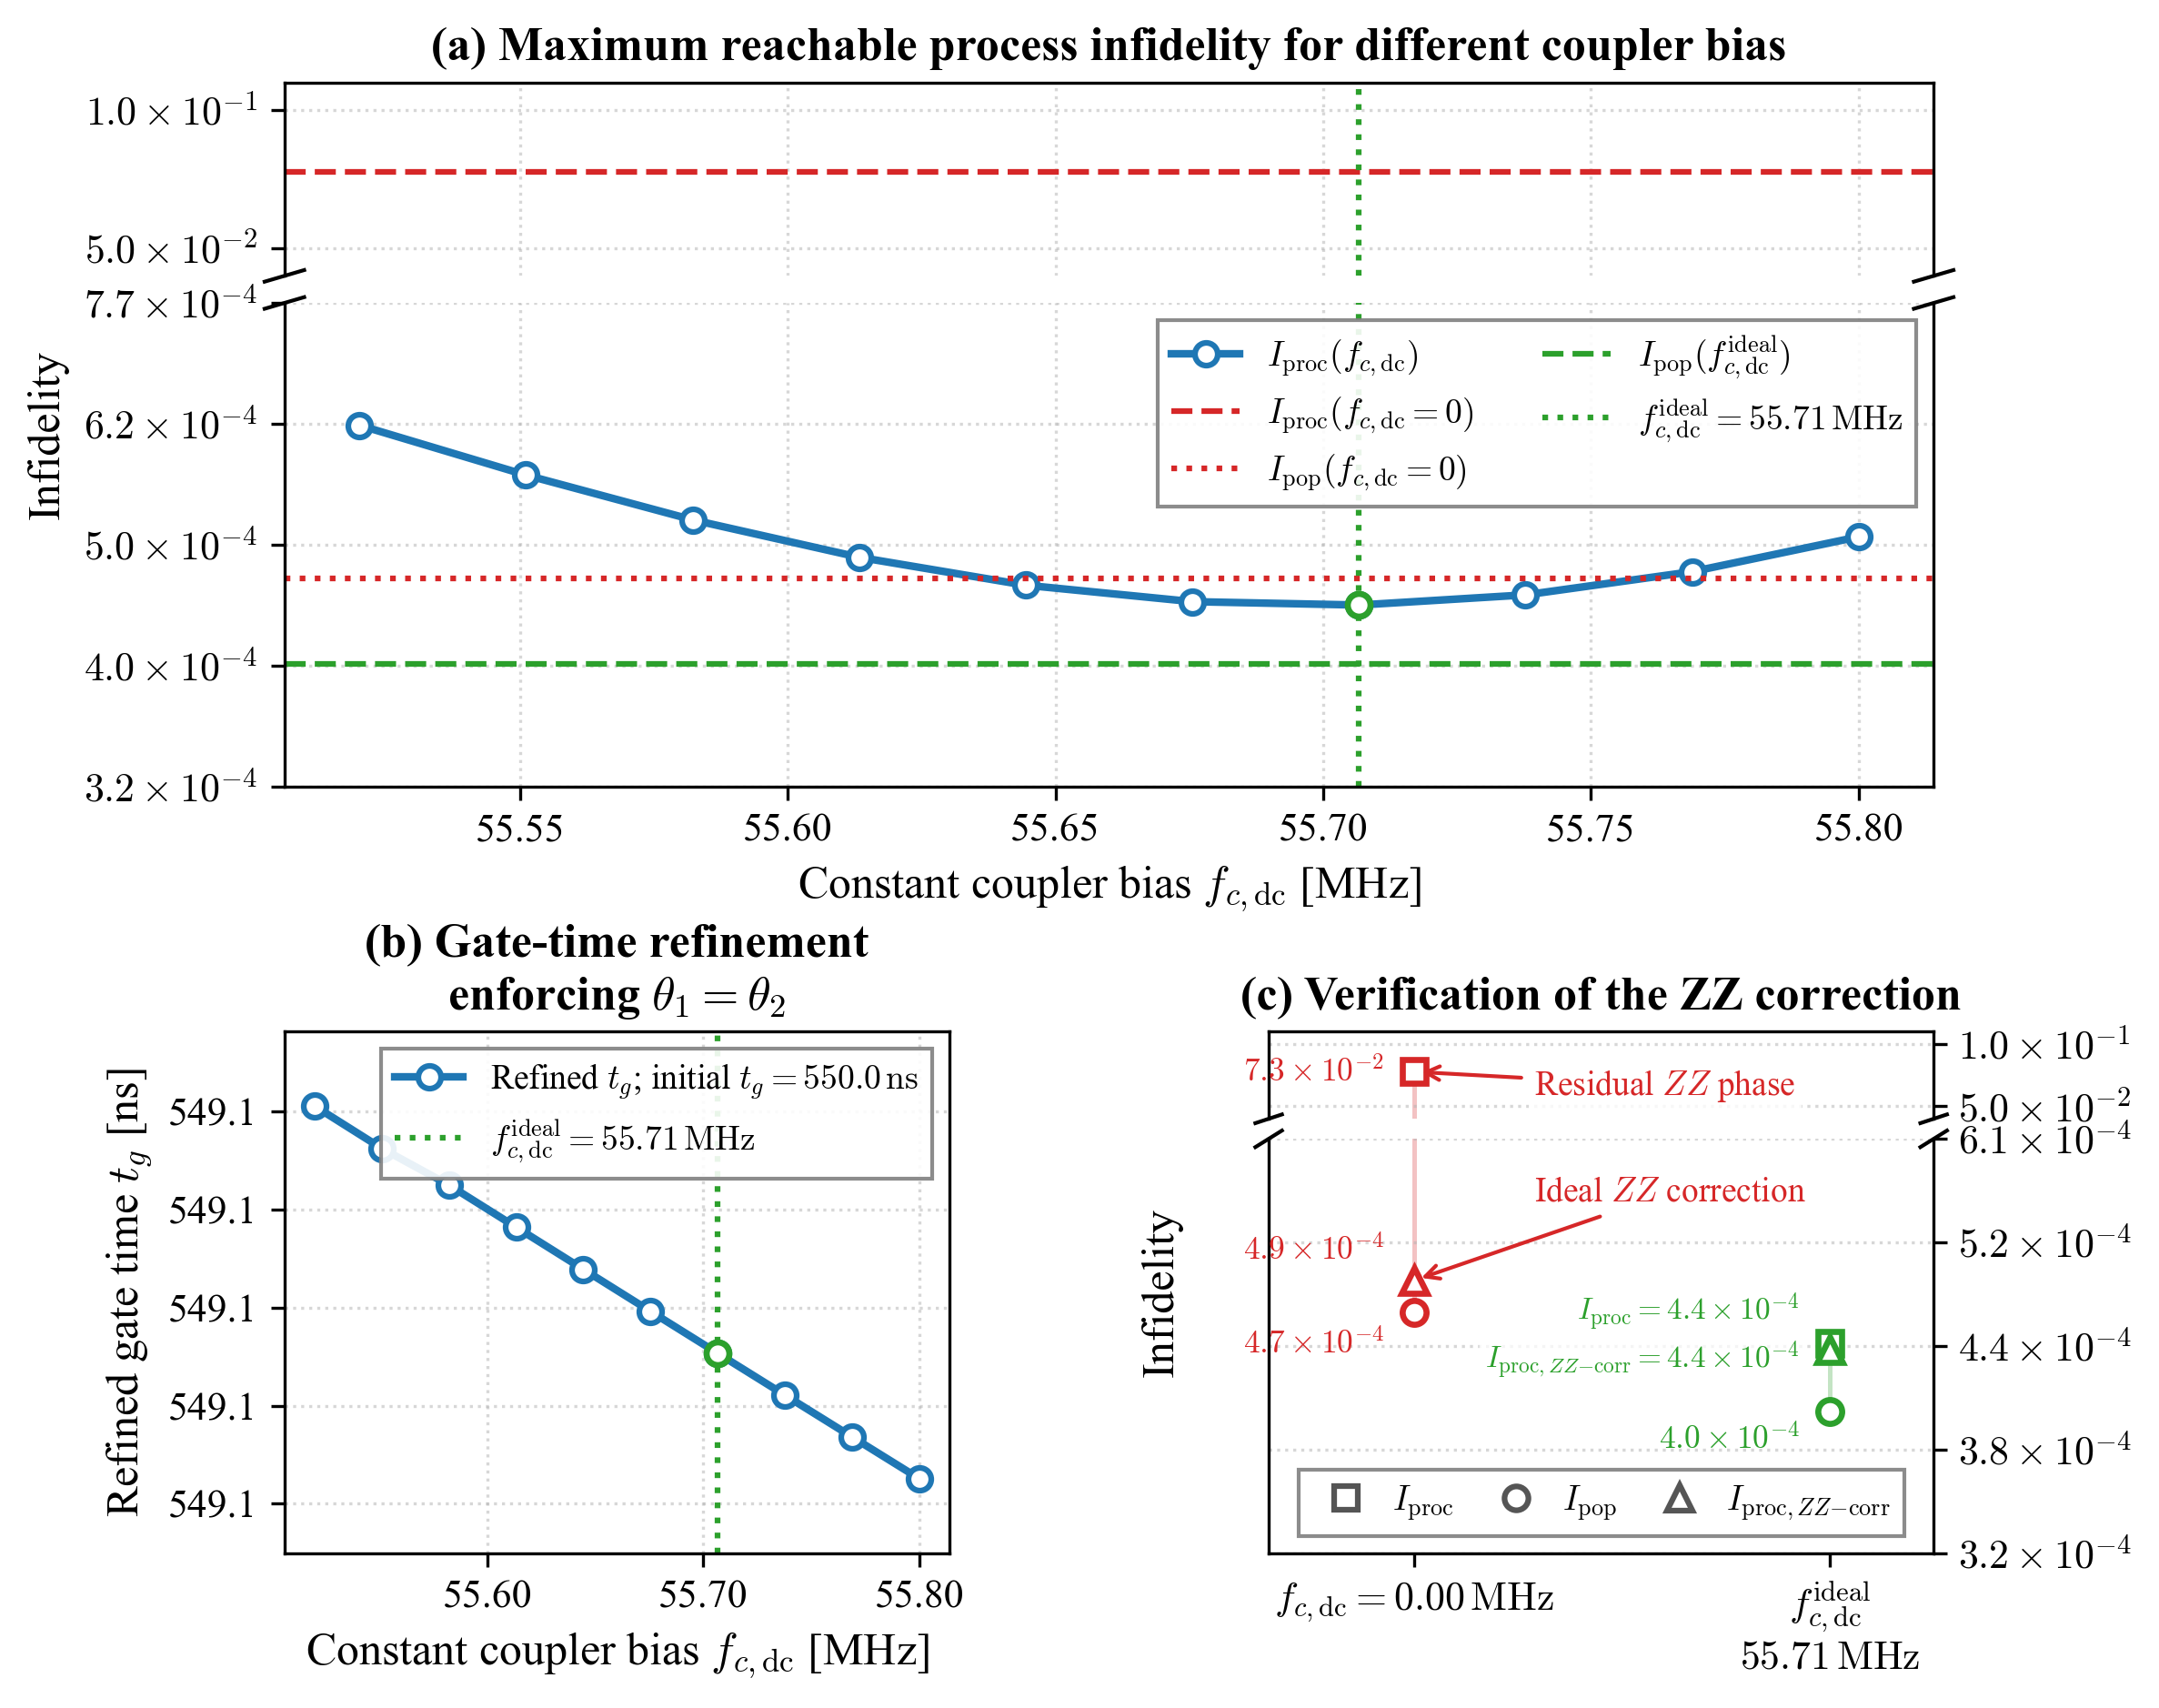

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker
from matplotlib.lines import Line2D

INFID_DECIMALS = 1
BIAS_DECIMALS = 2
TIME_DECIMALS = 1


def setup_paper_style():
    """Sets Matplotlib defaults matching the reference paper style."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "font.size": 11,
        "axes.labelsize": 12.0,
        "axes.titlesize": 12.5,
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "legend.fontsize": 9.0,
        "lines.linewidth": 2.0,
        "lines.markersize": 6.0,
        "axes.linewidth": 0.8,
    })


def _extract_zz_corrected_key(d):
    """Finds the ZZ-corrected key even with surrounding spaces."""
    for key in d.keys():
        if "infid_direct_proc_zz" in key:
            return key

    raise KeyError(
        "Could not find 'infid_direct_proc_zzcorrected' in dictionary keys."
    )


def _format_scientific(value, decimals=INFID_DECIMALS):
    """Formats numbers with a fixed number of mantissa decimal places."""
    if not np.isfinite(value) or value == 0.0:
        return rf"${value:.{decimals}f}$"

    exponent = int(np.floor(np.log10(abs(value))))
    mantissa = value / 10.0**exponent
    mantissa = round(mantissa, decimals)

    if abs(mantissa) >= 10.0:
        mantissa /= 10.0
        exponent += 1

    return rf"${mantissa:.{decimals}f}\times10^{{{exponent}}}$"


def _nice_outer_log_ticks(values):
    """Returns two smooth ticks of the form 1, 2 or 5 times a power of ten."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0.0)]

    if len(values) == 0:
        raise ValueError(
            "No positive finite values available for logarithmic scaling."
        )

    value_min = np.min(values)
    value_max = np.max(values)

    if np.isclose(np.log10(value_min), np.log10(value_max)):
        target_min = value_min / 1.35
        target_max = value_max * 1.35
    else:
        target_min = value_min
        target_max = value_max

    exponent_min = int(np.floor(np.log10(target_min))) - 1
    exponent_max = int(np.ceil(np.log10(target_max))) + 1

    candidates = np.array([
        mantissa * 10.0**exponent
        for exponent in range(exponent_min, exponent_max + 1)
        for mantissa in (1.0, 2.0, 5.0)
    ])

    candidates.sort()

    lower_candidates = candidates[candidates <= target_min]
    upper_candidates = candidates[candidates >= target_max]

    lower_tick = lower_candidates[-1]
    upper_tick = upper_candidates[0]

    if np.isclose(lower_tick, upper_tick):
        index = int(np.where(np.isclose(candidates, lower_tick))[0][0])
        lower_tick = candidates[max(0, index - 1)]
        upper_tick = candidates[min(len(candidates) - 1, index + 1)]

    return np.array([lower_tick, upper_tick])


def _set_clean_log_segment(ax, values, num_ticks=2):
    """Sets logarithmically scaled segment with specified number of ticks evenly distributed."""
    ax.set_yscale("log")

    if num_ticks == 2:
        ticks = _nice_outer_log_ticks(values)
        ax.set_ylim(ticks[0] / 1.15, ticks[-1] * 1.15)
    else:
        # Dynamisches Margin basierend auf Datenbereich
        val_min, val_max = np.min(values), np.max(values)
        if np.isclose(val_min, val_max):
            val_min /= 2.0
            val_max *= 2.0

        y_min = val_min / 1.25
        y_max = val_max * 1.25
        ax.set_ylim(y_min, y_max)

        # Verteilt num_ticks exakt gleichmäßig über den Y-Limits-Platz
        ticks = np.geomspace(y_min, y_max, num=num_ticks)

    ax.yaxis.set_major_locator(ticker.FixedLocator(ticks))
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda value, position: _format_scientific(value))
    )
    ax.yaxis.set_minor_locator(ticker.NullLocator())
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())


def _draw_axis_break(ax_top, ax_bottom, size=0.012):
    """Draws diagonal marks between two vertically stacked axes."""
    ax_top.spines["bottom"].set_visible(False)
    ax_bottom.spines["top"].set_visible(False)

    ax_top.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    ax_bottom.tick_params(axis="x", which="both", top=False)

    top_kwargs = {
        "transform": ax_top.transAxes,
        "color": "black",
        "clip_on": False,
        "linewidth": 1.0,
    }

    ax_top.plot((-size, +size), (-2.5 * size, +2.5 * size), **top_kwargs)
    ax_top.plot((1 - size, 1 + size), (-2.5 * size, +2.5 * size), **top_kwargs)

    bottom_kwargs = {
        "transform": ax_bottom.transAxes,
        "color": "black",
        "clip_on": False,
        "linewidth": 1.0,
    }

    ax_bottom.plot((-size, +size), (1 - size, 1 + size), **bottom_kwargs)
    ax_bottom.plot((1 - size, 1 + size), (1 - size, 1 + size), **bottom_kwargs)


def plot_constant_bias_fidelity_results(
    f_c_dc_list,
    sweep_data_bias,
    zero_bias_result,
    tg_base=550.0,
    save_path="Figure/constant_bias_fidelity_comparison.pdf",
    show=True,
):
    setup_paper_style()

    # Copies prevent accidental modification of the expensive sweep data.
    bias_ghz = np.array(f_c_dc_list, dtype=float, copy=True)
    bias_mhz = 1e3 * bias_ghz
    data = {
        key.strip(): np.array(value, copy=True)
        for key, value in sweep_data_bias.items()
    }

    required_keys = ["infid_direct_proc", "infid_direct_pop", "tg_final"]
    missing_keys = [key for key in required_keys if key not in data]

    if missing_keys:
        raise KeyError(f"Missing sweep-data keys: {missing_keys}")

    if any(len(data[key]) != len(bias_ghz) for key in required_keys):
        raise ValueError(
            "All sweep arrays must have the same length as f_c_dc_list."
        )

    proc_sweep = np.asarray(data["infid_direct_proc"], dtype=float)
    pop_sweep = np.asarray(data["infid_direct_pop"], dtype=float)
    tg_sweep = np.asarray(data["tg_final"], dtype=float)

    # Optimal bias from the minimum direct process infidelity.
    ideal_idx = int(np.nanargmin(proc_sweep))
    ideal_bias_ghz = float(bias_ghz[ideal_idx])
    ideal_bias_mhz = 1e3 * ideal_bias_ghz

    # Zero-bias values.
    zero_proc = float(zero_bias_result["infid_direct_proc"])
    zero_pop = float(zero_bias_result["infid_direct_pop"])
    zero_tg = float(zero_bias_result["tg_final"])
    zero_zz_key = _extract_zz_corrected_key(zero_bias_result)
    zero_zz = float(zero_bias_result[zero_zz_key])

    # Optimal-bias values.
    ideal_proc = float(proc_sweep[ideal_idx])
    ideal_pop = float(pop_sweep[ideal_idx])
    ideal_tg = float(tg_sweep[ideal_idx])
    sweep_zz_key = _extract_zz_corrected_key(data)
    ideal_zz = float(data[sweep_zz_key][ideal_idx])

    plotted_infidelities = np.concatenate((
        proc_sweep,
        [zero_proc, zero_pop, zero_zz, ideal_proc, ideal_pop, ideal_zz],
    ))

    if np.any(~np.isfinite(plotted_infidelities)) or np.any(
        plotted_infidelities <= 0.0
    ):
        raise ValueError("All plotted infidelities must be positive and finite.")

    ideal_bias_text = f"{ideal_bias_mhz:.{BIAS_DECIMALS}f}"
    zero_bias_text = f"{0.0:.{BIAS_DECIMALS}f}"
    tg_base_text = f"{tg_base:.{TIME_DECIMALS}f}"

    # Same palette as in the reference plot.
    c_sweep = "#1f77b4"
    c_zero = "#d62728"
    c_ideal = "#2ca02c"
    c_neutral = "#555555"

    mark_stride = max(1, len(bias_mhz) // 25)

    plot_style = {
        "axes.labelsize": 12.0,
        "axes.titlesize": 12.5,
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "legend.fontsize": 9.0,
        "lines.linewidth": 2.0,
        "lines.markersize": 6.0,
    }

    with plt.rc_context(plot_style):
        fig = plt.figure(figsize=(7.8, 7.0), dpi=300)

        outer_grid = fig.add_gridspec(
            2, 1, height_ratios=[1.35, 1.0], hspace=0.40
        )

        # Panel (a): broken logarithmic y-axis.
        grid_a = outer_grid[0].subgridspec(
            2, 1, height_ratios=[1.0, 2.5], hspace=0.08
        )
        ax_proc_top = fig.add_subplot(grid_a[0])
        ax_proc_bot = fig.add_subplot(grid_a[1], sharex=ax_proc_top)

        # Panels (b) and (c).
        grid_bc = outer_grid[1].subgridspec(1, 2, wspace=0.48)
        ax_tg = fig.add_subplot(grid_bc[0])

        grid_c = grid_bc[1].subgridspec(
            2, 1, height_ratios=[0.80, 3.80], hspace=0.08
        )
        ax_compare_top = fig.add_subplot(grid_c[0])
        ax_compare_bot = fig.add_subplot(grid_c[1], sharex=ax_compare_top)

        # ------------------------------------------------------------------
        # (a) Direct process infidelity versus constant coupler bias
        # ------------------------------------------------------------------

        for ax in (ax_proc_top, ax_proc_bot):
            ax.semilogy(
                bias_mhz,
                proc_sweep,
                "-",
                color=c_sweep,
                marker="o",
                markevery=mark_stride,
                mfc="white",
                mec=c_sweep,
                mew=1.5,
                label=r"$I_{\mathrm{proc}}(f_{c,\mathrm{dc}})$",
            )
            ax.axhline(
                zero_proc,
                color=c_zero,
                linestyle="--",
                linewidth=1.5,
                label=r"$I_{\mathrm{proc}}(f_{c,\mathrm{dc}}=0)$",
            )
            ax.axhline(
                zero_pop,
                color=c_zero,
                linestyle=":",
                linewidth=1.5,
                label=r"$I_{\mathrm{pop}}(f_{c,\mathrm{dc}}=0)$",
            )
            ax.axhline(
                ideal_pop,
                color=c_ideal,
                linestyle="--",
                linewidth=1.5,
                label=r"$I_{\mathrm{pop}}(f_{c,\mathrm{dc}}^{\mathrm{ideal}})$",
            )
            ax.axvline(
                ideal_bias_mhz,
                color=c_ideal,
                linestyle=":",
                linewidth=1.5,
                label=rf"$f_{{c,\mathrm{{dc}}}}^{{\mathrm{{ideal}}}}={ideal_bias_text}\,\mathrm{{MHz}}$",
            )
            ax.plot(
                ideal_bias_mhz,
                ideal_proc,
                "o",
                color=c_ideal,
                mfc="white",
                mec=c_ideal,
                mew=1.6,
                zorder=4,
            )
            ax.grid(
                True, which="major", linestyle=":", alpha=0.50, linewidth=0.8
            )

        lower_a_values = np.concatenate((proc_sweep, [zero_pop, ideal_pop]))

        _set_clean_log_segment(ax_proc_top, [zero_proc], num_ticks=2)
        _set_clean_log_segment(ax_proc_bot, lower_a_values, num_ticks=5)
        _draw_axis_break(ax_proc_top, ax_proc_bot, size=0.012)

        ax_proc_bot.xaxis.set_major_formatter(
            ticker.FormatStrFormatter(f"%.{BIAS_DECIMALS}f")
        )
        ax_proc_bot.set_xlabel(
            r"Constant coupler bias $f_{c,\mathrm{dc}}$ [MHz]"
        )
        ax_proc_top.set_title(
            r"(a) Maximum reachable process infidelity for different coupler"
            r" bias",
            fontweight="bold",
        )
        ax_proc_bot.legend(
            loc="upper right",
            ncol=2,
            frameon=True,
            fancybox=False,
            edgecolor="gray",
            framealpha=0.9,
        )

        # ------------------------------------------------------------------
        # (b) Gate-time refinement
        # ------------------------------------------------------------------

        ax_tg.plot(
            bias_mhz,
            tg_sweep,
            "-",
            color=c_sweep,
            marker="o",
            markevery=mark_stride,
            mfc="white",
            mec=c_sweep,
            mew=1.5,
            label=rf"Refined $t_g$; initial $t_g={tg_base_text}\,\mathrm{{ns}}$",
        )
        ax_tg.plot(
            ideal_bias_mhz,
            ideal_tg,
            "o",
            color=c_ideal,
            mfc="white",
            mec=c_ideal,
            mew=1.6,
            zorder=4,
        )
        ax_tg.axvline(
            ideal_bias_mhz,
            color=c_ideal,
            linestyle=":",
            linewidth=1.5,
            label=rf"$f_{{c,\mathrm{{dc}}}}^{{\mathrm{{ideal}}}}={ideal_bias_text}\,\mathrm{{MHz}}$",
        )

        tg_min = np.min(tg_sweep)
        tg_max = np.max(tg_sweep)
        tg_range = tg_max - tg_min

        if tg_range < 1e-9:
            ax_tg.set_ylim(tg_min - 0.1, tg_max + 0.1)
        else:
            ax_tg.set_ylim(tg_min - 0.2 * tg_range, tg_max + 0.2 * tg_range)

        ax_tg.xaxis.set_major_formatter(
            ticker.FormatStrFormatter(f"%.{BIAS_DECIMALS}f")
        )
        ax_tg.yaxis.set_major_formatter(
            ticker.FormatStrFormatter(f"%.{TIME_DECIMALS}f")
        )
        ax_tg.set_xlabel(r"Constant coupler bias $f_{c,\mathrm{dc}}$ [MHz]")
        ax_tg.set_ylabel(r"Refined gate time $t_g$ [ns]")
        ax_tg.set_title(
            r"(b) Gate-time refinement"
            "\n"
            r"enforcing $\theta_1=\theta_2$",
            fontweight="bold",
        )
        ax_tg.grid(True, linestyle=":", alpha=0.50, linewidth=0.8)
        ax_tg.legend(
            loc="best",
            frameon=True,
            fancybox=False,
            edgecolor="gray",
            framealpha=0.9,
        )

        # ------------------------------------------------------------------
        # (c) Direct zero-bias / ideal-bias comparison
        # ------------------------------------------------------------------

        x_positions = np.array([0.0, 1.0])
        proc_values = np.array([zero_proc, ideal_proc])
        pop_values = np.array([zero_pop, ideal_pop])
        zz_values = np.array([zero_zz, ideal_zz])
        bias_colors = [c_zero, c_ideal]

        for ax in (ax_compare_top, ax_compare_bot):
            for x_pos, color, proc_value, pop_value, zz_value in zip(
                x_positions, bias_colors, proc_values, pop_values, zz_values
            ):
                values = np.array([proc_value, pop_value, zz_value])
                ax.plot(
                    [x_pos, x_pos],
                    [np.min(values), np.max(values)],
                    "-",
                    color=color,
                    linewidth=1.2,
                    alpha=0.28,
                    zorder=1,
                )
                ax.semilogy(
                    x_pos,
                    proc_value,
                    "s",
                    color=color,
                    mfc="white",
                    mec=color,
                    mew=1.6,
                    ms=6.3,
                    zorder=3,
                )
                ax.semilogy(
                    x_pos,
                    pop_value,
                    "o",
                    color=color,
                    mfc="white",
                    mec=color,
                    mew=1.6,
                    ms=6.3,
                    zorder=3,
                )
                ax.semilogy(
                    x_pos,
                    zz_value,
                    "^",
                    color=color,
                    mfc="white",
                    mec=color,
                    mew=1.6,
                    ms=6.5,
                    zorder=3,
                )

            ax.grid(
                True,
                which="major",
                axis="y",
                linestyle=":",
                alpha=0.50,
                linewidth=0.8,
            )

        lower_c_values = np.array(
            [ideal_proc, zero_pop, ideal_pop, zero_zz, ideal_zz]
        )

        _set_clean_log_segment(ax_compare_top, [zero_proc], num_ticks=2)
        _set_clean_log_segment(ax_compare_bot, lower_c_values, num_ticks=5)
        _draw_axis_break(ax_compare_top, ax_compare_bot, size=0.020)

        for ax in (ax_compare_top, ax_compare_bot):
            ax.yaxis.tick_right()
            ax.tick_params(axis="y", labelleft=False, labelright=True, pad=3)

        # Numerical annotations: one uniform scientific format.
        ax_compare_top.annotate(
            _format_scientific(zero_proc),
            xy=(0.0, zero_proc),
            xytext=(-8, 0),
            textcoords="offset points",
            fontsize=8.5,
            color=c_zero,
            ha="right",
            va="center",
        )

        ax_compare_bot.annotate(
            _format_scientific(zero_zz),
            xy=(0.0, zero_zz),
            xytext=(-8, 4),
            textcoords="offset points",
            fontsize=8.5,
            color=c_zero,
            ha="right",
            va="bottom",
        )
        ax_compare_bot.annotate(
            _format_scientific(zero_pop),
            xy=(0.0, zero_pop),
            xytext=(-8, -4),
            textcoords="offset points",
            fontsize=8.5,
            color=c_zero,
            ha="right",
            va="top",
        )

        rel_diff_ideal = abs(ideal_proc - ideal_zz) / max(ideal_proc, ideal_zz)

        if rel_diff_ideal < 0.15:
            combined_text = (
                r"$I_{{\mathrm{{proc}}}}="
                f"{_format_scientific(ideal_proc).strip('$')}$\n"
                r"$I_{{\mathrm{{proc}},ZZ\mathrm{{-corr}}}}="
                f"{_format_scientific(ideal_zz).strip('$')}$"
            )

            ax_compare_bot.annotate(
                combined_text,
                xy=(1.0, ideal_proc),
                xytext=(-8, 2),
                textcoords="offset points",
                fontsize=8.0,
                color=c_ideal,
                ha="right",
                va="center",
                bbox={
                    "boxstyle": "round,pad=0.2",
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.75,
                },
            )
        else:
            ax_compare_bot.annotate(
                _format_scientific(ideal_proc),
                xy=(1.0, ideal_proc),
                xytext=(-8, 4),
                textcoords="offset points",
                fontsize=8.5,
                color=c_ideal,
                ha="right",
                va="bottom",
            )
            ax_compare_bot.annotate(
                _format_scientific(ideal_zz),
                xy=(1.0, ideal_zz),
                xytext=(-8, -4),
                textcoords="offset points",
                fontsize=8.5,
                color=c_ideal,
                ha="right",
                va="top",
            )

        ax_compare_bot.annotate(
            _format_scientific(ideal_pop),
            xy=(1.0, ideal_pop),
            xytext=(-8, -3),
            textcoords="offset points",
            fontsize=8.5,
            color=c_ideal,
            ha="right",
            va="top",
        )

        annotation_box = {
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.82,
            "pad": 1.5,
        }

        ax_compare_top.annotate(
            r"Residual $ZZ$ phase",
            xy=(0.0, zero_proc),
            xytext=(0.40, 0.28),
            textcoords="axes fraction",
            arrowprops={
                "arrowstyle": "->",
                "color": c_zero,
                "linewidth": 1.0,
            },
            fontsize=9.0,
            color=c_zero,
            bbox=annotation_box,
        )
        ax_compare_bot.annotate(
            r"Ideal $ZZ$ correction",
            xy=(0.0, zero_zz),
            xytext=(0.40, 0.85),
            textcoords="axes fraction",
            arrowprops={
                "arrowstyle": "->",
                "color": c_zero,
                "linewidth": 1.0,
            },
            fontsize=9.0,
            color=c_zero,
            bbox=annotation_box,
        )

        metric_handles = [
            Line2D(
                [],
                [],
                linestyle="none",
                marker="s",
                mfc="white",
                mec=c_neutral,
                mew=1.5,
                ms=6.3,
                label=r"$I_{\mathrm{proc}}$",
            ),
            Line2D(
                [],
                [],
                linestyle="none",
                marker="o",
                mfc="white",
                mec=c_neutral,
                mew=1.5,
                ms=6.3,
                label=r"$I_{\mathrm{pop}}$",
            ),
            Line2D(
                [],
                [],
                linestyle="none",
                marker="^",
                mfc="white",
                mec=c_neutral,
                mew=1.5,
                ms=6.5,
                label=r"$I_{\mathrm{proc},ZZ\mathrm{-corr}}$",
            ),
        ]

        ax_compare_top.set_title(
            r"(c) Verification of the ZZ correction", fontweight="bold"
        )
        ax_compare_bot.set_xticks(x_positions)
        ax_compare_bot.set_xticklabels([
            rf"$f_{{c,\mathrm{{dc}}}}={zero_bias_text}\,\mathrm{{MHz}}$",
            r"$f_{c,\mathrm{dc}}^{\mathrm{ideal}}$"
            + "\n"
            + rf"${ideal_bias_text}\,\mathrm{{MHz}}$",
        ])
        ax_compare_bot.set_xlim(-0.35, 1.25)
        ax_compare_bot.legend(
            handles=metric_handles,
            loc="lower center",
            ncol=3,
            frameon=True,
            fancybox=False,
            edgecolor="gray",
            framealpha=0.9,
            handletextpad=0.35,
            columnspacing=0.85,
        )

        # Achsentitel für Panel (c) auf der linken Seite des rechten Plots setzen (verhindert jede Überlappung)
        compare_top_pos = ax_compare_top.get_position()
        compare_bot_pos = ax_compare_bot.get_position()
        compare_mid_y = 0.5 * (compare_bot_pos.y0 + compare_top_pos.y1)

        fig.text(
            compare_bot_pos.x0 - 0.05,
            compare_mid_y,
            r"Infidelity",
            va="center",
            ha="center",
            rotation="vertical",
            fontsize=12.0,
        )

        fig.tight_layout(rect=(0.045, 0.02, 0.98, 1.0))

        # Shared y-label for panel (a).
        proc_top_position = ax_proc_top.get_position()
        proc_bot_position = ax_proc_bot.get_position()
        proc_label_y = 0.5 * (proc_bot_position.y0 + proc_top_position.y1)
        fig.text(
            0.014,
            proc_label_y,
            r"Infidelity",
            va="center",
            ha="center",
            rotation="vertical",
            fontsize=12.0,
        )

        if save_path:
            output_file = Path(save_path)
            output_file.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(output_file, bbox_inches="tight")

        if show:
            plt.show()

    summary = {
        "ideal_bias_ghz": ideal_bias_ghz,
        "ideal_bias_mhz": ideal_bias_mhz,
        "ideal_process_infidelity": ideal_proc,
        "ideal_population_infidelity": ideal_pop,
        "ideal_zz_corrected_infidelity": ideal_zz,
        "zero_bias_process_infidelity": zero_proc,
        "zero_bias_population_infidelity": zero_pop,
        "zero_bias_zz_corrected_infidelity": zero_zz,
        "base_gate_time_ns": tg_base,
        "zero_bias_gate_time_ns": zero_tg,
        "ideal_bias_gate_time_ns": ideal_tg,
    }

    return fig, (ax_proc_bot, ax_tg, ax_compare_bot), summary


fig, axes, comparison_summary = plot_constant_bias_fidelity_results(
    f_c_dc_list,
    sweep_data_bias,
    dic,
    tg_base=tg_fixed,
    save_path="Figure/2/constant_bias_fidelity_comparison.pdf",
)

In [7]:
tg = 0
s = Simulation()
tg_list = np.linspace(50.0, 700.0, 30)
infid_pop_list = []
infid_floq_pop_list = []

def for_tg(tg, ):
    cos_wd, cos_amp = compute_cos_params(s,tg)
    best_params, infid_floq_pop = optimize_pulse_parameters(*bind_tg_fixed_floquet_functions(tg, s), param_ranges, s, tg)
    amp = best_params["amp_scale"] * cos_amp
    wd = best_params["wd_offset"] + cos_wd
    q_sig = lambda t, args=None: amp * np.cos(wd * t)
    n_pts_mes = max(101, int(np.ceil(tg * 40)))
    U_direct = np.zeros((4, 4), dtype=complex)
    for j in range(4):
        result = sesolve([s.H0, [s.V1, q_sig]], s.E_states[s.comp_indices[j]], np.linspace(0.0, tg, n_pts_mes), e_ops=[])
        amplitudes = np.array([[state.overlap(psi_t) for psi_t in result.states] for state in s.E_states[s.comp_indices]])
        U_direct[:, j] = amplitudes[:, -1]
    infid_direct_pop = infid_population(U_direct)
    return infid_floq_pop, infid_direct_pop, best_params

for tg in tqdm(tg_list):
    infid_floq_pop, infid_direct_pop, _ = for_tg(tg)
    infid_pop_list.append(infid_direct_pop)
    infid_floq_pop_list.append(infid_floq_pop)

save_dir = Path("operational_res")
save_dir.mkdir(parents=True, exist_ok=True)
save_file = save_dir / "cos_popfids_data.npz"
# Daten als komprimiertes NumPy-Archiv speichern
np.savez(
    save_file, 
    tg_list=tg_list, 
    infid_pop_list=np.array(infid_pop_list)
)
print(f"Daten erfolgreich gespeichert unter: {save_file}")

100%|██████████| 30/30 [02:33<00:00,  5.10s/it]

Daten erfolgreich gespeichert unter: operational_res/cos_popfids_data.npz


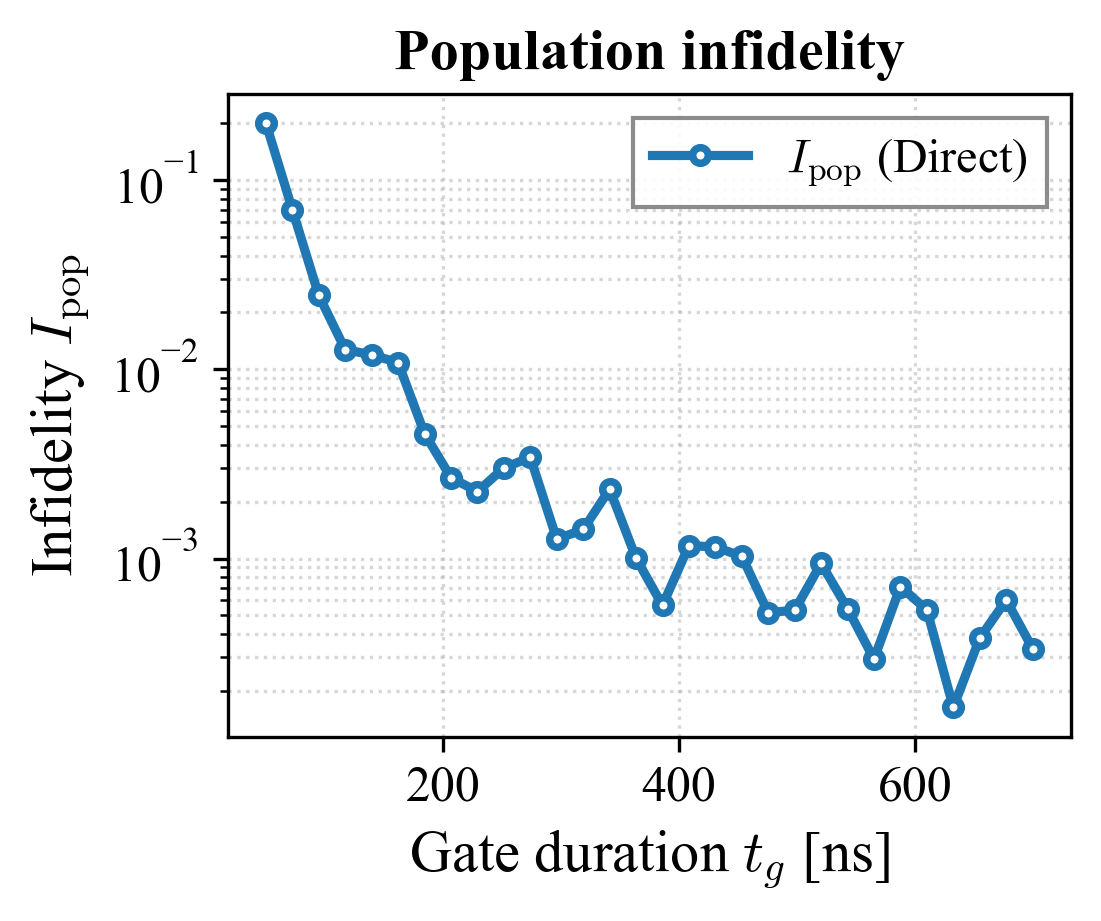

In [8]:
def plot_infidelity_vs_tg_margin(tg_list, infid_pop_list, save_path=None, show=True):
    # Standard-Paper-Style laden
    setup_paper_style()
    
    c_proc = "#1f77b4"
    
    # 1. Schriftgrößen und Liniendicken gezielt für schmale Margin-Plots hochskalieren
    margin_style = {
        "axes.labelsize": 14.0,       # Achsenbeschriftungen (tg, I_pop) deutlich größer
        "axes.titlesize": 14.0,       # Titel größer
        "xtick.labelsize": 12.0,      # Zahlen an den Ticks größer
        "ytick.labelsize": 12.0,
        "legend.fontsize": 11.5,      # Legende lesbar halten
        "lines.linewidth": 2.2,       # Dickere Linie für schmale Darstellung
        "lines.markersize": 7.5,      # Größere Marker
    }
    
    with plt.rc_context(margin_style):
        # Kompaktes Figure-Format für die Spaltenbreite des Seitenrands
        fig, ax = plt.subplots(figsize=(3.8, 3.2), dpi=300)
        
        ax.semilogy(
            tg_list, 
            infid_pop_list, 
            "-", 
            color=c_proc, 
            marker=".", 
            markerfacecolor="white", 
            markeredgecolor=c_proc,
            markeredgewidth=1.8,
            label=r"$I_{\mathrm{pop}}$ (Direct)"
        )
        
        ax.set_xlabel(r"Gate duration $t_g$ [ns]")
        ax.set_ylabel(r"Infidelity $I_{\mathrm{pop}}$")
        ax.set_title(r"Population infidelity", fontweight="bold")
        
        ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.8)
        ax.legend(loc="best", frameon=True, fancybox=False, edgecolor="gray", framealpha=0.9)
        
        # Etwas mehr Platz für die Achsenbeschriftungen lassen
        fig.tight_layout()
        
        if save_path:
            output_file = Path(save_path)
            output_file.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(output_file, bbox_inches="tight")
            
        if show:
            plt.show()
            
        return fig, ax

# Ausführen
fig, ax = plot_infidelity_vs_tg_margin(tg_list, infid_pop_list, save_path="Figure/cosine_pop_infidelity_vs_tg.pdf")

Determine optimal parameters for $t_g=200$~ns

In [9]:
inf_direct, inf_floquet, p_opt = for_tg(200,)
print("floquet: ", inf_floquet, " direct: ", inf_direct, " p_opt: ", p_opt)

floquet:  0.005164076161201181  direct:  0.002217259054399068  p_opt:  {'wd_offset': np.float64(0.00025938826800108274), 'amp_scale': np.float64(1.0268684650089668)}
